# 02 - Exploratory Data Analysis

Compare control and experiment groups across all metrics before running formal tests.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import config
from src.data_loader import load_cleaned, split_groups

df   = load_cleaned()
ctrl, exp = split_groups(df)

CC = config.CONTROL_COLOR
EC = config.EXPERIMENT_COLOR
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

## 1. Group summary table

In [2]:
summary = df.groupby('group').agg(
    users        =('user_id', 'count'),
    conversions  =('converted', 'sum'),
    conv_rate    =('converted', 'mean'),
    avg_revenue  =('revenue', 'mean'),
    avg_session  =('session_time_min', 'mean'),
    avg_pages    =('pages_viewed', 'mean')
).round(4)
print("Group Summary:")
summary

Group Summary:


,users,conversions,conv_rate,avg_revenue,avg_session,avg_pages
group,,,,,,
control,4800,541,0.1127,5.6654,8.8951,4.0894
experiment,5200,745,0.1433,8.6286,10.5812,4.6158


## 2. Conversion rate comparison

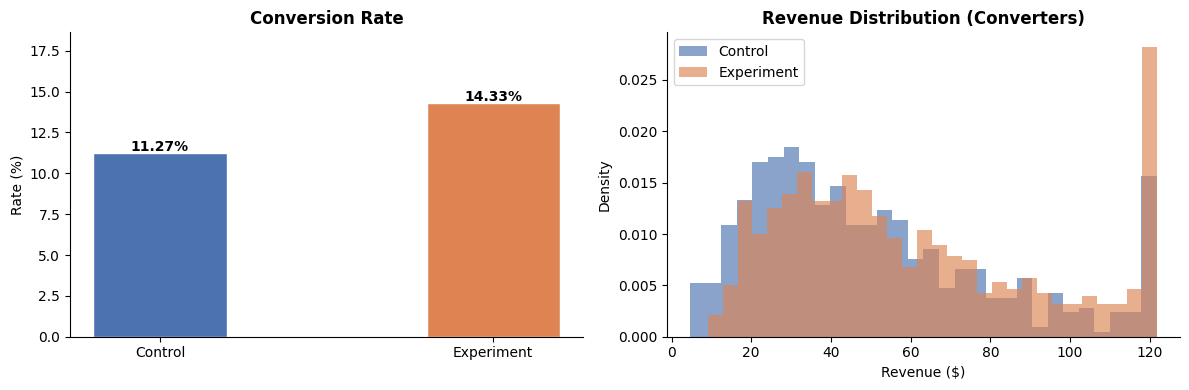

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rates = [ctrl['converted'].mean()*100, exp['converted'].mean()*100]
bars = axes[0].bar(['Control', 'Experiment'], rates, color=[CC, EC], width=0.4, edgecolor='white')
for b, v in zip(bars, rates):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                 f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].set_title('Conversion Rate', fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_ylim(0, max(rates)*1.3)

rev_ctrl = ctrl[ctrl['revenue'] > 0]['revenue']
rev_exp  = exp[exp['revenue'] > 0]['revenue']
axes[1].hist(rev_ctrl, bins=30, alpha=0.65, color=CC, label='Control',    density=True)
axes[1].hist(rev_exp,  bins=30, alpha=0.65, color=EC,  label='Experiment', density=True)
axes[1].set_title('Revenue Distribution (Converters)', fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../' + config.IMAGES_DIR + 'eda_overview.png', bbox_inches='tight')
plt.show()

## 3. Engagement metrics

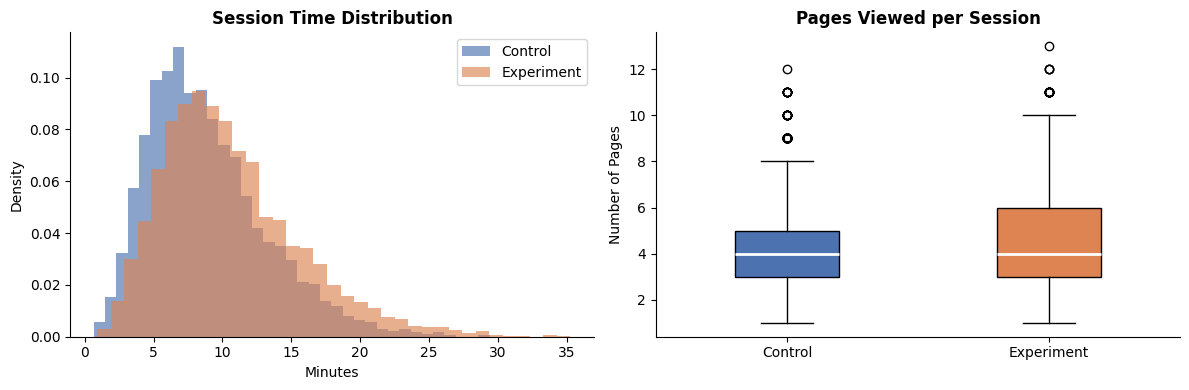

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ctrl['session_time_min'], bins=35, alpha=0.65, color=CC, label='Control',    density=True)
axes[0].hist(exp['session_time_min'],  bins=35, alpha=0.65, color=EC,  label='Experiment', density=True)
axes[0].set_title('Session Time Distribution', fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Density')
axes[0].legend()

pages_data = [ctrl['pages_viewed'], exp['pages_viewed']]
bp = axes[1].boxplot(pages_data, patch_artist=True, widths=0.4,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(CC)
bp['boxes'][1].set_facecolor(EC)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Control', 'Experiment'])
axes[1].set_title('Pages Viewed per Session', fontweight='bold')
axes[1].set_ylabel('Number of Pages')

plt.tight_layout()
plt.savefig('../' + config.IMAGES_DIR + 'eda_engagement.png', bbox_inches='tight')
plt.show()